In [1]:
import numpy as np
import pandas as pd


In [2]:
from google.colab import files
upload= files.upload()

Saving QVI_purchase_behaviour.csv to QVI_purchase_behaviour.csv


In [3]:
df1=pd.read_csv('QVI_purchase_behaviour.csv')

In [4]:
upload= files.upload()

Saving QVI_transaction_data.csv to QVI_transaction_data.csv


In [5]:
df2=pd.read_csv('QVI_transaction_data.csv')

In [6]:
df1.head(5)

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [7]:
df2.head(5)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [8]:
df2=df2.rename(columns={'DATE': 'ID'})

In [9]:
df= pd.merge(df2,df1,on='LYLTY_CARD_NBR')

In [10]:
df.head(5)

,ID,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget


In [11]:
df[['ID','STORE_NBR','LYLTY_CARD_NBR','TXN_ID','PROD_NBR']]=df[['ID','STORE_NBR','LYLTY_CARD_NBR','TXN_ID','PROD_NBR']].astype(str)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   ID                264836 non-null  object 
 1   STORE_NBR         264836 non-null  object 
 2   LYLTY_CARD_NBR    264836 non-null  object 
 3   TXN_ID            264836 non-null  object 
 4   PROD_NBR          264836 non-null  object 
 5   PROD_NAME         264836 non-null  object 
 6   PROD_QTY          264836 non-null  int64  
 7   TOT_SALES         264836 non-null  float64
 8   LIFESTAGE         264836 non-null  object 
 9   PREMIUM_CUSTOMER  264836 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 20.2+ MB


In [13]:
df.isnull().sum()

,0
ID,0
STORE_NBR,0
LYLTY_CARD_NBR,0
TXN_ID,0
PROD_NBR,0
PROD_NAME,0
PROD_QTY,0
TOT_SALES,0
LIFESTAGE,0
PREMIUM_CUSTOMER,0


In [14]:
df.describe()

,PROD_QTY,TOT_SALES
count,264836.000000,264836.000000
mean,1.907309,7.304200
std,0.643654,3.083226
min,1.000000,1.500000
25%,2.000000,5.400000
50%,2.000000,7.400000
75%,2.000000,9.200000
max,200.000000,650.000000


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

{'whiskers': [<matplotlib.lines.Line2D at 0x78baa06c8e30>,
 'caps': [<matplotlib.lines.Line2D at 0x78baa06c9400>,
 'boxes': [<matplotlib.lines.Line2D at 0x78baa06c8b30>,
 'medians': [<matplotlib.lines.Line2D at 0x78baa06c98e0>,
 'fliers': [<matplotlib.lines.Line2D at 0x78baa06ca120>,
 'means': []}

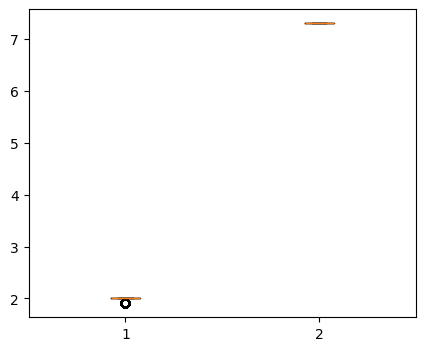

In [21]:
plt.figure(figsize=(5,4))
plt.boxplot(df[['PROD_QTY','TOT_SALES']])


In [17]:
def replace_outliers_with_mean(df,column):
  q1= df['PROD_QTY'].quantile(0.25)
  q3= df['PROD_QTY'].quantile(0.75)
  IQR=q3-q1
  lower_bound=q1-1.5*IQR
  upper_bound=q3+1.5*IQR
  mean_value=df[column].mean()
  df[column] = df[column].apply(lambda x: mean_value if x < lower_bound or x > upper_bound else x)

  return df

In [18]:
replace_outliers_with_mean(df,'PROD_QTY')
replace_outliers_with_mean(df,'TOT_SALES')

,ID,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2.000000,7.3042,YOUNG SINGLES/COUPLES,Premium
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,1.907309,7.3042,MIDAGE SINGLES/COUPLES,Budget
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2.000000,7.3042,MIDAGE SINGLES/COUPLES,Budget
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,1.907309,7.3042,MIDAGE SINGLES/COUPLES,Budget
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,1.907309,7.3042,MIDAGE SINGLES/COUPLES,Budget
...,...,...,...,...,...,...,...,...,...,...
264831,43533,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2.000000,7.3042,YOUNG SINGLES/COUPLES,Premium
264832,43325,272,272358,270154,74,Tostitos Splash Of Lime 175g,1.907309,7.3042,YOUNG SINGLES/COUPLES,Premium
264833,43410,272,272379,270187,51,Doritos Mexicana 170g,2.000000,7.3042,YOUNG SINGLES/COUPLES,Premium
264834,43461,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2.000000,7.3042,YOUNG SINGLES/COUPLES,Premium


In [19]:
df = df[df['PROD_NAME'].str.contains('chips', case=False, na=False)]

In [22]:
df.head(5)

,ID,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2.000000,7.3042,MIDAGE SINGLES/COUPLES,Budget
6,43601,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1.907309,7.3042,MIDAGE SINGLES/COUPLES,Budget
10,43602,7,7215,7176,16,Smiths Crinkle Chips Salt & Vinegar 330g,1.907309,7.3042,MIDAGE SINGLES/COUPLES,Budget
14,43600,19,19272,16686,44,Thins Chips Light& Tangy 175g,1.907309,7.3042,MIDAGE SINGLES/COUPLES,Budget
33,43603,45,45220,41651,22,Thins Chips Originl saltd 175g,1.907309,7.3042,MIDAGE SINGLES/COUPLES,Budget


In [28]:
df['LYLTY_CARD_NBR'].value_counts()

,count
LYLTY_CARD_NBR,
144121,7
191027,7
269249,6
247003,6
138182,6
...,...
266432,1
267345,1
268011,1


In [39]:

customer_sales = df.groupby(['ID','PREMIUM_CUSTOMER'])['TOT_SALES'].sum().reset_index()

high_sales_customers = pd.DataFrame(customer_sales.sort_values(by='TOT_SALES', ascending=False)).head(10)
high_sales_customers

,ID,PREMIUM_CUSTOMER,TOT_SALES
529,43458,Mainstream,584.335966
637,43495,Mainstream,547.814969
526,43457,Mainstream,540.510769
319,43388,Mainstream,533.206569
19,43288,Mainstream,533.206569
1020,43623,Budget,525.902370
523,43456,Mainstream,518.598170
70,43305,Mainstream,518.598170
511,43452,Mainstream,518.598170
1075,43641,Mainstream,503.989771


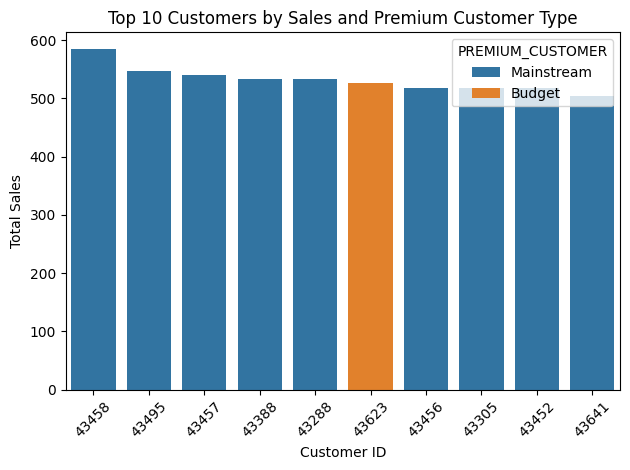

In [41]:
sns.barplot(data=high_sales_customers, x='ID', y='TOT_SALES', hue='PREMIUM_CUSTOMER')
plt.title('Top 10 Customers by Sales and Premium Customer Type')
plt.xlabel('Customer ID')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()